In [1]:
!pwd

/home/vramon/notebooks/WebNLG_MT_eval/audit/QA_evaluation/audit_notebooks/aligned


# QA1 — Resource integrity and recurring-component consistency (text-aligned v2)

This notebook implements the QA1 metrics described in the thesis text using the shared QA1.1 and QA1.2 metric implementations.

- English source triple parity is reported only as a preprocessing sanity check.
- Target record integrity combines target triple parity, target-text presence, lexicalisation-ID alignment, lexicalisation-ID uniqueness, and target triple-set well-formedness (an audit-specific RDF-field sanity check).
- Recurring-component consistency reports item-level dominant mapping rate, occurrence-weighted corpus dominance, and a derived mapping-review flag.

English RDF is always read from `modifiedtripleset/mtriple`.

In [2]:

from __future__ import annotations

from collections import defaultdict
from pathlib import Path
import hashlib
import importlib
import importlib.util
import json
import os
import sys
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)


def find_repo_root() -> Path:
    override = Path("/home/vramon/notebooks/WebNLG_MT_eval")
    if override:
        root = Path(override).expanduser().resolve()
        if not (root / "WebNLG_CA_BT").exists():
            raise FileNotFoundError(
                f"WebNLG_CA_BT was not found under {root}"
            )
        return root

    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "WebNLG_CA_BT").exists():
            return candidate.resolve()

    mounted = Path("/mnt/data/RDF-to-text-MT-Evaluation-main")
    if mounted.exists():
        return mounted.resolve()

    raise FileNotFoundError(
        "Repository root not found. Set WEBNLG_REPO_ROOT."
    )


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "WebNLG_CA_BT"
CORE_PATH = (
    REPO_ROOT
    / "audit"
    / "QA_evaluation"
    / "audit_notebooks"
    / "aligned"
    / "audit_metric_core.py"
)
QA11_CORE_PATH = CORE_PATH.with_name("qa11_metric_core.py")

for required_path, label in (
    (CORE_PATH, "Shared metric core"),
    (QA11_CORE_PATH, "Shared QA1.1 metric core"),
):
    if not required_path.exists():
        raise FileNotFoundError(
            f"{label} not found: {required_path}\n"
            "Copy the supplied Python files into "
            "audit/QA_evaluation/audit_notebooks/aligned/."
        )

spec = importlib.util.spec_from_file_location(
    "audit_metric_core",
    CORE_PATH,
)
core = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = core
spec.loader.exec_module(core)

qa11_spec = importlib.util.spec_from_file_location(
    "qa11_metric_core",
    QA11_CORE_PATH,
)
qa11_core = importlib.util.module_from_spec(qa11_spec)
sys.modules[qa11_spec.name] = qa11_core
qa11_spec.loader.exec_module(qa11_core)

# Fail early if either shared implementation has drifted from the
# corresponding QA1 table.
qa11_core.assert_well_formedness_contract(
    core.triple_well_formed
)
core.assert_qa12_metric_contract()

CORE_SHA256 = hashlib.sha256(
    CORE_PATH.read_bytes()
).hexdigest()
QA11_CORE_SHA256 = hashlib.sha256(
    QA11_CORE_PATH.read_bytes()
).hexdigest()

print("Repository root:", REPO_ROOT)
print("Metric core:", CORE_PATH)
print("Metric compatibility:", core.CORE_COMPATIBILITY)
print("Metric core SHA-256:", CORE_SHA256)
print("QA1.1 metric core:", QA11_CORE_PATH)
print("QA1.1 metric-core SHA-256:", QA11_CORE_SHA256)

RESULTS_NAME = os.getenv(
    "QA1_RESULTS_NAME",
    "QA1_stress_aligned",
)
RESULTS_DIR = (
    REPO_ROOT
    / "QA_evaluation"
    / "results"
    / RESULTS_NAME
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# QA1.2 evaluates only recurring source components. QA12_MIN_RECURRING
# is the preferred variable; QA1_MIN_RECURRING is retained as a
# backward-compatible fallback.
MIN_RECURRING_OCCURRENCES = int(
    os.getenv(
        "QA12_MIN_RECURRING",
        os.getenv("QA1_MIN_RECURRING", "2"),
    )
)
if MIN_RECURRING_OCCURRENCES < 2:
    raise ValueError(
        "QA1.2 requires a recurrence threshold of at least 2."
    )

RANDOM_SEED = 42

print("Results directory:", RESULTS_DIR)
print(
    "QA1.2 recurrence threshold:",
    MIN_RECURRING_OCCURRENCES,
)


Repository root: /home/vramon/notebooks/WebNLG_MT_eval
Metric core: /home/vramon/notebooks/WebNLG_MT_eval/audit/QA_evaluation/audit_notebooks/aligned/audit_metric_core.py
Metric compatibility: audit-text-aligned-2.3
Metric core SHA-256: 01f3f23fa4f051b90b874018e9f4911a0152dd1c9160b65dc437fcc7866b5a9d
QA1.1 metric core: /home/vramon/notebooks/WebNLG_MT_eval/audit/QA_evaluation/audit_notebooks/aligned/qa11_metric_core.py
QA1.1 metric-core SHA-256: 078dd7453ce1ad03a147aa3d3ca6b1a1ddd0bc1b71a30d70cba179bdf375d6ad
Results directory: /home/vramon/notebooks/WebNLG_MT_eval/QA_evaluation/results/QA1_stress_aligned
QA1.2 recurrence threshold: 2


## 1. Parse the original aligned resources

In [3]:

TARGET_LANGUAGES = {
    "es": {
        "label": "Spanish",
        "triple_set": "spanishtripleset",
        "triple_tag": "striple",
    },
    "ca": {
        "label": "Catalan",
        "triple_set": "catalantripleset",
        "triple_tag": "ctriple",
    },
}


def list_corpus_xml_files(root: Path):
    usable, ignored = [], []
    for path in root.rglob("*.xml"):
        relative = path.relative_to(root)
        if (
            any(part.startswith(".") for part in relative.parts)
            or path.name.endswith("-checkpoint.xml")
        ):
            ignored.append(path)
        else:
            usable.append(path)
    return sorted(usable), sorted(ignored)


def node_texts(entry, xpath: str):
    return [
        (node.text or "").strip()
        for node in entry.findall(xpath)
    ]


def lexicalisation_pairs(entry):
    result = defaultdict(list)
    for node in entry.findall("lex"):
        language = (node.get("lang") or "").strip()
        lid = (node.get("lid") or "").strip()
        text = (node.text or "").strip()
        if language:
            result[language].append((lid, text))
    return result


def build_clean_manifest(data_root: Path):
    rows = []
    qa11_rows = []
    mapping_rows = []
    entry_rows = []
    parse_errors = []
    xml_files, ignored_files = list_corpus_xml_files(data_root)

    for xml_path in xml_files:
        relative = xml_path.relative_to(data_root)
        split = relative.parts[0] if relative.parts else "unknown"
        triple_bucket = (
            relative.parts[1]
            if len(relative.parts) > 1
            else "unknown"
        )
        try:
            root = ET.parse(xml_path).getroot()
        except ET.ParseError as exc:
            parse_errors.append({
                "xml_path": relative.as_posix(),
                "error": str(exc),
            })
            continue

        for entry in root.findall(".//entry"):
            eid = (entry.get("eid") or "").strip()
            category = (entry.get("category") or "").strip()
            source_triples = node_texts(
                entry,
                ".//modifiedtripleset/mtriple",
            )

            size_raw = (entry.get("size") or "").strip()
            try:
                declared_size = int(size_raw)
                declared_size_valid = declared_size >= 0
            except (TypeError, ValueError):
                declared_size = None
                declared_size_valid = False

            expected_triple_count = (
                declared_size
                if declared_size_valid
                else len(source_triples)
            )

            lexicalisations = lexicalisation_pairs(entry)
            english_pairs = lexicalisations.get("en", [])
            english_lids = [
                lid for lid, _ in english_pairs
            ]
            english_by_lid = defaultdict(list)
            for lid, text in english_pairs:
                english_by_lid[lid].append(text)

            record_key = f"{relative.as_posix()}::{eid}"
            entry_row = {
                "record_key": record_key,
                "xml_path": relative.as_posix(),
                "split": split,
                "triple_bucket": triple_bucket,
                "category": category,
                "eid": eid,
                "declared_size_raw": size_raw,
                "declared_size": declared_size,
                "declared_size_valid": declared_size_valid,
                "expected_triple_count": expected_triple_count,
                "source_triple_count": len(source_triples),
                "english_lexicalisations": len(english_pairs),
                "english_lids_unique": (
                    len(english_pairs)
                    == len(set(english_lids))
                    and all(english_lids)
                ),
            }

            for language, config in TARGET_LANGUAGES.items():
                target_triples = node_texts(
                    entry,
                    f".//{config['triple_set']}/"
                    f"{config['triple_tag']}",
                )
                target_pairs = lexicalisations.get(language, [])
                target_lids = [
                    lid for lid, _ in target_pairs
                ]
                target_texts = [
                    text for _, text in target_pairs
                ]

                target_by_lid = defaultdict(list)
                for lid, text in target_pairs:
                    target_by_lid[lid].append(text)

                entry_row.update({
                    f"{language}_target_triple_count": (
                        len(target_triples)
                    ),
                    f"{language}_target_lexicalisations": (
                        len(target_pairs)
                    ),
                    f"{language}_target_lids_unique": (
                        len(target_pairs)
                        == len(set(target_lids))
                        and all(target_lids)
                    ),
                    f"{language}_lid_set_equal": (
                        set(english_lids)
                        == set(target_lids)
                    ),
                })

                # One QA1.1 row per RDF entry and target language.
                qa11_rows.append({
                    "record_key": record_key,
                    "xml_path": relative.as_posix(),
                    "split": split,
                    "triple_bucket": triple_bucket,
                    "category": category,
                    "eid": eid,
                    "language": language,
                    "language_label": config["label"],
                    "declared_size_raw": size_raw,
                    "declared_size": declared_size,
                    "declared_size_valid": declared_size_valid,
                    "expected_triple_count": expected_triple_count,
                    "source_triples": list(source_triples),
                    "target_triples": list(target_triples),
                    "english_lids": list(english_lids),
                    "target_lids": list(target_lids),
                    "target_texts": list(target_texts),
                })

                # Lexicalisation-level rows remain available for QA2/QA3 and
                # for tracing each aligned text pair.
                all_lids = sorted(
                    set(english_by_lid)
                    | set(target_by_lid)
                )
                for lid in all_lids:
                    source_texts = english_by_lid.get(lid, [])
                    target_texts_for_lid = target_by_lid.get(lid, [])
                    source_lid = lid if source_texts else ""
                    target_lid = lid if target_texts_for_lid else ""
                    source_text = (
                        source_texts[0] if source_texts else ""
                    )
                    target_text = (
                        target_texts_for_lid[0]
                        if target_texts_for_lid
                        else ""
                    )
                    digest = hashlib.sha1(
                        (
                            f"{record_key}|{lid}|{language}"
                        ).encode("utf-8")
                    ).hexdigest()[:12]
                    rows.append({
                        "variant_id": (
                            f"original__{language}__{digest}"
                        ),
                        "base_pair_key": (
                            f"{record_key}::{lid}"
                        ),
                        "record_key": record_key,
                        "language": language,
                        "language_label": config["label"],
                        "qa_track": "CLEAN",
                        "corruption_type": "clean",
                        "severity": "clean",
                        # Kept for backward compatibility with later notebooks.
                        "declared_size": expected_triple_count,
                        "declared_size_raw": size_raw,
                        "declared_size_valid": declared_size_valid,
                        "expected_triple_count": expected_triple_count,
                        "source_lid": source_lid,
                        "variant_lid": target_lid,
                        "source_triples": source_triples,
                        "clean_target_triples": target_triples,
                        "variant_target_triples": target_triples,
                        "source_text": source_text,
                        "clean_target_text": target_text,
                        "variant_target_text": target_text,
                        "xml_duplicate_target_lex": (
                            len(target_texts_for_lid) > 1
                        ),
                        "xml_path": relative.as_posix(),
                        "split": split,
                        "triple_bucket": triple_bucket,
                        "category": category,
                        "eid": eid,
                        "is_benign": False,
                        "consistency_group_id": "",
                        "perturbation_pair_id": "",
                        "removed_token_fraction": np.nan,
                        "alternative_reference_lid": "",
                        "alternative_source_text": "",
                    })

                if (
                    len(source_triples)
                    == len(target_triples)
                    == expected_triple_count
                ):
                    for triple_index, (
                        source_triple,
                        target_triple,
                    ) in enumerate(
                        zip(source_triples, target_triples)
                    ):
                        source = core.split_triple(source_triple)
                        target = core.split_triple(target_triple)
                        for role, position in (
                            ("subject", 0),
                            ("predicate", 1),
                            ("object", 2),
                        ):
                            mapping_rows.append({
                                "record_key": record_key,
                                "xml_path": relative.as_posix(),
                                "split": split,
                                "category": category,
                                "language": language,
                                "language_label": config["label"],
                                "triple_index": triple_index,
                                "role": role,
                                "component_type": (
                                    "predicate"
                                    if role == "predicate"
                                    else "entity_or_value"
                                ),
                                "source_raw": source[position],
                                "target_raw": target[position],
                                "source_normalized": (
                                    core.normalize_label(
                                        source[position]
                                    )
                                ),
                                "target_normalized": (
                                    core.normalize_label(
                                        target[position]
                                    )
                                ),
                            })
            entry_rows.append(entry_row)

    manifest = pd.DataFrame(rows)
    aligned = manifest[
        manifest["source_lid"].ne("")
        & manifest["variant_lid"].ne("")
        & manifest["source_text"].map(
            lambda value: bool(core.normalize_space(value))
        )
        & manifest["variant_target_text"].map(
            lambda value: bool(core.normalize_space(value))
        )
        & manifest["source_triples"].map(bool)
        & manifest["variant_target_triples"].map(bool)
    ].copy()

    return {
        "manifest": manifest.reset_index(drop=True),
        "aligned": aligned.reset_index(drop=True),
        "qa11_entries": pd.DataFrame(qa11_rows),
        "mappings": pd.DataFrame(mapping_rows),
        "entries": pd.DataFrame(entry_rows),
        "ignored_xml": pd.DataFrame({
            "xml_path": [
                path.relative_to(data_root).as_posix()
                for path in ignored_files
            ]
        }),
        "parse_errors": pd.DataFrame(parse_errors),
    }


In [4]:

parsed = build_clean_manifest(DATA_ROOT)
manifest = parsed["manifest"]
aligned = parsed["aligned"]
qa11_entries = parsed["qa11_entries"]
mappings = parsed["mappings"]
entries = parsed["entries"]
ignored_xml = parsed["ignored_xml"]
parse_errors = parsed["parse_errors"]

print("Lexicalisation-level rows:", f"{len(manifest):,}")
print("QA1.1 entry-language rows:", f"{len(qa11_entries):,}")
print("Aligned lexicalisations:", f"{len(aligned):,}")
print("Mapping observations:", f"{len(mappings):,}")
print("XML parse errors:", len(parse_errors))

display(
    aligned.groupby(
        ["language", "language_label"],
        as_index=False,
    ).agg(
        lexicalisations=("variant_id", "size"),
        records=("record_key", "nunique"),
    )
)

display(
    qa11_entries.groupby(
        ["language", "language_label"],
        as_index=False,
    ).agg(
        rdf_entries=("record_key", "nunique"),
    )
)


Lexicalisation-level rows: 90,062
QA1.1 entry-language rows: 33,306
Aligned lexicalisations: 90,062
Mapping observations: 293,070
XML parse errors: 0


,language,language_label,lexicalisations,records
0,ca,Catalan,45031,16653
1,es,Spanish,45031,16653


,language,language_label,rdf_entries
0,ca,Catalan,16653
1,es,Spanish,16653


## 2. QA1.1 — Structural and instance integrity

Source triple parity is retained as a preprocessing sanity check but is excluded from the target-resource record-integrity conjunction.
QA1.1 is evaluated once per RDF entry and target language. The well-formedness component checks the corpus' pipe-delimited triple representation; it is not a complete RDF syntax validator.


,language,language_label,rdf_entries,entries_with_valid_declared_size,source_declared_parity_rate
0,ca,Catalan,16653,16653,1.0
1,es,Spanish,16653,16653,1.0


,language,language_label,rdf_entries,integrity_pass_rate,target_triple_parity_rate,target_text_present_rate,lexicalisation_id_alignment_rate,lexicalisation_id_unique_rate,target_rdf_well_formed_rate
0,ca,Catalan,16653,1.0,1.0,1.0,1.0,1.0,1.0
1,es,Spanish,16653,1.0,1.0,1.0,1.0,1.0,1.0


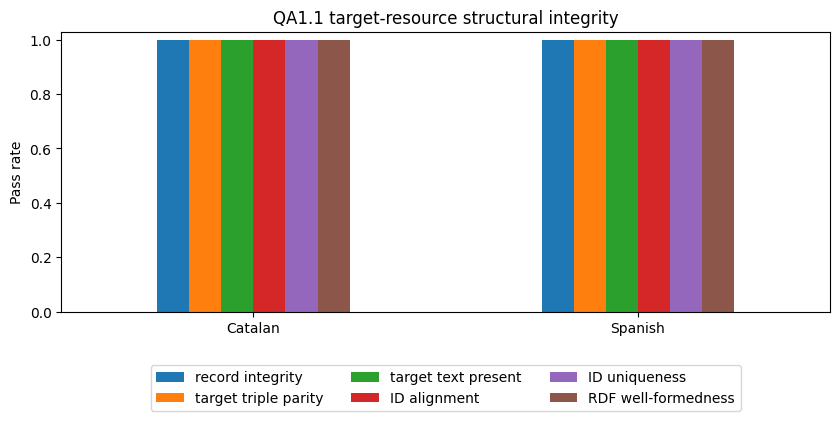

In [5]:

qa11 = qa11_entries.copy()
qa11["source_triple_count"] = qa11["source_triples"].map(len)
qa11["target_triple_count"] = qa11["target_triples"].map(len)

# Preprocessing sanity condition only. It is evaluated only where a valid
# declared size exists; fallback-derived expected counts are not treated as
# declared-size evidence.
qa11["source_declared_parity"] = pd.Series(
    pd.NA,
    index=qa11.index,
    dtype="boolean",
)
valid_declared = qa11["declared_size_valid"].fillna(False).astype(bool)
qa11.loc[valid_declared, "source_declared_parity"] = (
    qa11.loc[valid_declared, "source_triple_count"]
    == qa11.loc[valid_declared, "declared_size"].astype(int)
)

qa11_metric_rows = qa11.apply(
    lambda row: pd.Series(
        qa11_core.qa11_entry_metrics(
            expected_triple_count=row["expected_triple_count"],
            english_lids=row["english_lids"],
            target_lids=row["target_lids"],
            target_triples=row["target_triples"],
            target_texts=row["target_texts"],
            triple_well_formed_fn=core.triple_well_formed,
        )
    ),
    axis=1,
)
qa11 = pd.concat(
    [
        qa11.reset_index(drop=True),
        qa11_metric_rows.reset_index(drop=True),
    ],
    axis=1,
)

# Preserve a lexicalisation-level export for traceability by attaching the
# entry-level QA1.1 result to every lexicalisation row from that entry.
qa11_metric_columns = [
    "record_key",
    "language",
    "target_triple_parity",
    "target_text_present",
    "lexicalisation_id_alignment",
    "lexicalisation_id_unique",
    "target_rdf_well_formed",
    "record_integrity",
]
qa1 = manifest.merge(
    qa11[qa11_metric_columns],
    on=["record_key", "language"],
    how="left",
    validate="many_to_one",
)

source_sanity_summary = (
    qa11.groupby(["language", "language_label"], as_index=False)
    .agg(
        rdf_entries=("record_key", "nunique"),
        entries_with_valid_declared_size=(
            "declared_size_valid",
            "sum",
        ),
        source_declared_parity_rate=(
            "source_declared_parity",
            "mean",
        ),
    )
)

qa11_summary = (
    qa11.groupby(["language", "language_label"], as_index=False)
    .agg(
        rdf_entries=("record_key", "nunique"),
        integrity_pass_rate=("record_integrity", "mean"),
        target_triple_parity_rate=("target_triple_parity", "mean"),
        target_text_present_rate=("target_text_present", "mean"),
        lexicalisation_id_alignment_rate=(
            "lexicalisation_id_alignment", "mean"
        ),
        lexicalisation_id_unique_rate=(
            "lexicalisation_id_unique", "mean"
        ),
        target_rdf_well_formed_rate=(
            "target_rdf_well_formed", "mean"
        ),
    )
)

display(source_sanity_summary.round(6))
display(qa11_summary.round(6))

fig, ax = plt.subplots(figsize=(8.5, 4.6))
plot = qa11_summary.set_index("language_label")[[
    "integrity_pass_rate",
    "target_triple_parity_rate",
    "target_text_present_rate",
    "lexicalisation_id_alignment_rate",
    "lexicalisation_id_unique_rate",
    "target_rdf_well_formed_rate",
]]
plot.plot(kind="bar", ax=ax, rot=0)
ax.set_ylim(0, 1.03)
ax.set_ylabel("Pass rate")
ax.set_xlabel("")
ax.set_title("QA1.1 target-resource structural integrity")
ax.legend(
    [
        "record integrity",
        "target triple parity",
        "target text present",
        "ID alignment",
        "ID uniqueness",
        "RDF well-formedness",
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.38),
    ncol=3,
)
fig.tight_layout()
fig.savefig(
    RESULTS_DIR / "qa11_target_structural_integrity.pdf",
    bbox_inches="tight",
)
fig.savefig(
    RESULTS_DIR / "qa11_target_structural_integrity.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## 3. QA1.2 — Recurring-component consistency

Mapping observations are extracted from structurally aligned English and target triple sets. Triples are matched by position and components by role; the resulting source and target labels are normalised before recurring mappings are grouped by target language, reported component class, and source component.

The dominant mapping rate, occurrence-weighted dominant mapping rate, and derived mapping-review flag are all calculated by the shared `audit_metric_core.py`. The review flag only selects components with more than one observed target form for contextual inspection; it is not an automatic error label.


In [6]:
# Build one profile for every recurring source component x in each
# target language ell and reported component class r.
#
# The shared function calculates:
#   - n_{ell,r}(x): retained mapping occurrences;
#   - D_{ell,r}(x): dominant mapping rate; and
#   - M_{ell,r}(x): derived mapping-review flag.
mapping_profiles = core.qa12_build_mapping_profiles(
    mappings,
    minimum_occurrences=MIN_RECURRING_OCCURRENCES,
)

# Calculate D_{w,ell,r}, weighting each component-specific dominant
# mapping rate by its occurrence count.
qa12_summary = core.qa12_summarize_mapping_profiles(
    mapping_profiles
)

# Dataset-level checks complement the synthetic contract test above.
if not mapping_profiles.empty:
    if not (
        mapping_profiles["occurrences"]
        >= MIN_RECURRING_OCCURRENCES
    ).all():
        raise AssertionError(
            "QA1.2 returned a non-recurring source component."
        )

    expected_review_signal = (
        mapping_profiles["target_form_count"] > 1
    )
    if not (
        mapping_profiles["mapping_review_signal"]
        == expected_review_signal
    ).all():
        raise AssertionError(
            "The QA1.2 review flag is inconsistent with the "
            "observed target-form distribution."
        )

    rates = mapping_profiles["dominant_mapping_rate"]
    if not rates.between(0.0, 1.0, inclusive="both").all():
        raise AssertionError(
            "QA1.2 dominant mapping rates must lie in [0, 1]."
        )

if not qa12_summary.empty:
    weighted_rates = qa12_summary[
        "weighted_dominant_mapping_rate"
    ]
    if not weighted_rates.between(
        0.0,
        1.0,
        inclusive="both",
    ).all():
        raise AssertionError(
            "QA1.2 weighted dominant mapping rates must lie "
            "in [0, 1]."
        )

display(qa12_summary.round(6))

# M_{ell,r}(x) is used only to prepare the contextual-review subset.
variable_mappings = mapping_profiles[
    mapping_profiles["mapping_review_signal"]
].sort_values(
    [
        "language",
        "component_type",
        "dominant_mapping_rate",
        "occurrences",
    ],
    ascending=[True, True, True, False],
)
display(variable_mappings.head(30))


,language,language_label,component_type,recurring_source_items,mapping_observations,weighted_dominant_mapping_rate,mapping_review_rate,items_selected_for_review
0,ca,Catalan,entity_or_value,3458,97545,1.000000,0.000000,0
1,ca,Catalan,predicate,397,48831,1.000000,0.000000,0
2,es,Spanish,entity_or_value,3458,97545,0.999928,0.001446,5
3,es,Spanish,predicate,397,48831,1.000000,0.000000,0


,language,language_label,component_type,source_normalized,source_example,minimum_occurrences,occurrences,target_form_count,dominant_target_form,dominant_target_count,dominant_mapping_rate,mapping_review_signal,target_forms
6966,es,Spanish,entity_or_value,squid,Squid,2,7,2,calamar,6,0.857143,True,"{""calamar"": 6, ""teuthida"": 1}"
5390,es,Spanish,entity_or_value,central denmark region,Central_Denmark_Region,2,20,2,jutlandia central,19,0.950000,True,"{""dinamarca central"": 1, ""jutlandia central"": 19}"
7111,es,Spanish,entity_or_value,tomato,Tomato,2,42,2,tomate,40,0.952381,True,"{""solanum lycopersicum"": 2, ""tomate"": 40}"
4960,es,Spanish,entity_or_value,almond,Almond,2,52,2,almendra,51,0.980769,True,"{""almendra"": 51, ""prunus amygdalus"": 1}"
6772,es,Spanish,entity_or_value,rhythm and blues,Rhythm_and_blues,2,258,2,rhythm and blues,256,0.992248,True,"{""rhythm and blues"": 256, ""ritmo y blues"": 2}"


## 4. Export

In [7]:

qa1.to_csv(
    RESULTS_DIR / "qa1_original_variant_metrics.csv",
    index=False,
)
qa11.to_pickle(
    RESULTS_DIR / "qa11_original_entry_metrics.pkl",
)
qa11_csv = qa11.copy()
for column in [
    "source_triples",
    "target_triples",
    "english_lids",
    "target_lids",
    "target_texts",
]:
    qa11_csv[column] = qa11_csv[column].map(
        lambda value: json.dumps(value, ensure_ascii=False)
    )
qa11_csv.to_csv(
    RESULTS_DIR / "qa11_original_entry_metrics.csv",
    index=False,
)
source_sanity_summary.to_csv(
    RESULTS_DIR / "qa11_source_preprocessing_sanity.csv",
    index=False,
)
qa11_summary.to_csv(
    RESULTS_DIR / "qa11_original_structural_summary.csv",
    index=False,
)
mappings.to_csv(
    RESULTS_DIR / "qa12_component_mappings.csv",
    index=False,
)
mapping_profiles.to_csv(
    RESULTS_DIR / "qa12_mapping_profiles.csv",
    index=False,
)
qa12_summary.to_csv(
    RESULTS_DIR / "qa12_original_consistency_summary.csv",
    index=False,
)
variable_mappings.to_csv(
    RESULTS_DIR / "qa12_variable_mappings.csv",
    index=False,
)
entries.to_csv(
    RESULTS_DIR / "qa1_entry_inventory.csv",
    index=False,
)
ignored_xml.to_csv(
    RESULTS_DIR / "ignored_checkpoint_xml_files.csv",
    index=False,
)
parse_errors.to_csv(
    RESULTS_DIR / "xml_parse_errors.csv",
    index=False,
)

manual_mapping = variable_mappings.copy()
manual_mapping["manual_consistency_class"] = ""
manual_mapping["manual_notes"] = ""
manual_mapping.to_csv(
    RESULTS_DIR / "manual_qa12_variable_mappings.csv",
    index=False,
)

metadata = {
    "metric_core_compatibility": core.CORE_COMPATIBILITY,
    "metric_core_sha256": CORE_SHA256,
    "qa11_metric_core_sha256": QA11_CORE_SHA256,
    "source_rdf": "modifiedtripleset/mtriple",
    "qa11_evaluation_unit": "RDF entry and target language",
    "qa11_entry_language_rows": int(len(qa11)),
    "lexicalisation_level_rows": int(len(manifest)),
    "aligned_lexicalisations": int(len(aligned)),
    "record_integrity_components": [
        "target_triple_parity",
        "target_text_present",
        "lexicalisation_id_alignment",
        "lexicalisation_id_unique",
        "target_rdf_well_formed",
    ],
    "source_parity_role": "preprocessing sanity only",
    "expected_triple_count_rule": (
        "declared entry size; English modified-triple count "
        "when the declared value is missing or malformed"
    ),
    "qa12_evaluation_unit": (
        "target language, reported component class, "
        "and recurring normalized English component"
    ),
    "qa12_mapping_alignment": (
        "structurally aligned English and target triple sets; "
        "triples aligned by position and components by role"
    ),
    "qa12_component_classes": sorted(
        mappings["component_type"].dropna().unique().tolist()
    ),
    "qa12_mapping_observations": int(len(mappings)),
    "qa12_recurring_profiles": int(len(mapping_profiles)),
    "qa12_metrics": [
        "dominant_mapping_rate",
        "weighted_dominant_mapping_rate",
        "mapping_review_signal",
    ],
    "qa12_shared_metric_core": True,
    "minimum_recurring_occurrences": (
        MIN_RECURRING_OCCURRENCES
    ),
}
(
    RESULTS_DIR / "qa1_run_metadata.json"
).write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

print("Saved QA1 outputs to", RESULTS_DIR)


Saved QA1 outputs to /home/vramon/notebooks/WebNLG_MT_eval/QA_evaluation/results/QA1_stress_aligned
